# Bays (2024) Figure 5 — Diagnosing the $\mathrm{SD}_{\mathrm{normal}}$ Plateau (Bays vs GP)

**Goal.** Reproduce Figure 5 of Ma, Husain & Bays (2014, *Nat Neurosci*) using **two model pipelines run in parallel** under the same diagnostic protocol:

1. **Bays (2014) parametric population coding model.**
2. **Our GP-based population coding model.**

This is the same Bays-vs-GP equivalence comparison used throughout the thesis. Here it is applied to the $\mathrm{SD}_{\mathrm{normal}}$-plateau diagnostic: a methodological test that asks whether a particular way of *summarising* recall errors can be trusted to distinguish between competing accounts of working memory.

## What Figure 5 is about

A popular analysis pipeline for visual working memory data fits the Zhang & Luck (2008) **normal–uniform mixture**

$$
p(\epsilon) \;=\; w \cdot \mathrm{VonMises}(\epsilon;\, 0, \kappa) \;+\; (1-w) \cdot \frac{1}{2\pi}.
$$

From the fitted $\kappa$ one reads off $\mathrm{SD}_{\mathrm{normal}}$, intended as the precision of "stored" items, while $1-w$ is interpreted as the "guess" rate. Figure 5 of Ma, Husain & Bays (2014) shows that as set size $\ell$ grows:

- $\mathrm{SD}_{\mathrm{actual}}$ (the model-free circular SD of the raw errors) climbs steeply,
- $\mathrm{SD}_{\mathrm{normal}}$ (read off the fitted mixture) rises and then *plateaus*,
- $w$ drops — the mixture starts attributing errors to "guessing".

The plateau was used to argue for slot models: *"precision is fixed, extra items just fail to be stored."* The original paper's Figure 5(c) rebuts this by showing the same plateau pattern is produced by a continuous-resource model that contains **no slots and no item limit** — confirming the plateau is an artifact of fitting a misspecified mixture, not a signature of slots.

## What this notebook does

Both model pipelines are continuous-resource population coding models without slots. Running both through the identical diagnostic pipeline lets us check two things at once:

- That **each** model independently reproduces the $\mathrm{SD}_{\mathrm{normal}}$ plateau (so the diagnostic conclusion in Ma, Husain & Bays 2014 carries over to both architectures).
- That the **Bays and GP variants** produce quantitatively similar $\mathrm{SD}_{\mathrm{actual}}$ / $\mathrm{SD}_{\mathrm{normal}}$ curves under the protocol — the equivalence check that anchors the thesis.

## Layout

- **Row 1 — Bays parametric.** (a) aggregate-error distribution + mixture fit. (b) $\mathrm{SD}_{\mathrm{actual}}$ vs $\mathrm{SD}_{\mathrm{normal}}$ across set sizes.
- **Row 2 — GP variant.** Same two panels for the GP-based population.

## Note on the citation

The paper is Ma, Husain & Bays (2014, *Nat Neurosci*); a number of internal references in this project use the shorthand "Bays 2024" for the 2024 review article that re-presents the same figure. The diagnostic logic and figure are from the 2014 paper.

## Imports & setup

In [1]:
import sys
from pathlib import Path
from datetime import datetime

# Project root is two levels above this notebook
# (notebook lives in equivalence_model_v0.1/experiments/<something>/).
PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import i0, i1
from scipy.optimize import minimize, least_squares

from core.population import Population

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Output directory

Results (figure + per-set-size summary) go to `result_data/bays_fig5_<timestamp>/`, matching the project's convention used by the other experiment notebooks.

In [2]:
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = PROJECT_ROOT / "result_data" / f"bays_fig5_{TIMESTAMP}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data/bays_fig5_20260602_180656


## Circular statistics and the Zhang & Luck mixture fit

In [3]:
def circular_sd(errors):
    """Fisher (1995) circular SD: sigma = sqrt(-2 log |m1|)."""
    R = np.abs(np.mean(np.exp(1j * np.asarray(errors))))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def kappa_to_circular_sd(kappa):
    """Von Mises concentration kappa -> Fisher circular SD."""
    if kappa < 1e-6:
        return np.sqrt(-2.0 * np.log(1e-15))
    if kappa > 700:
        kappa = 700.0
    R = float(i1(kappa) / i0(kappa))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def _neg_log_lik_mixture(unconstrained_params, errors):
    """Negative log likelihood of the normal-uniform mixture, with logit/log transforms."""
    logit_w, log_kappa = unconstrained_params
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)

    vm = np.exp(kappa * np.cos(errors)) / (2.0 * np.pi * i0(kappa))
    uniform = 1.0 / (2.0 * np.pi)
    mix = w * vm + (1.0 - w) * uniform

    return -np.sum(np.log(np.maximum(mix, 1e-300)))


def fit_normal_uniform_mixture(errors, init_w=0.85, init_kappa=10.0):
    """
    ML fit of the Zhang & Luck (2008) normal-uniform mixture.

    Returns
    -------
    w : float in (0, 1)
        Weight on the Von Mises ("stored") component.
    kappa : float > 0
        Von Mises concentration.
    sd_normal : float
        Circular SD corresponding to kappa.
    """
    errors = np.asarray(errors)
    logit_w0 = np.log(init_w / (1.0 - init_w))
    log_kappa0 = np.log(init_kappa)
    x0 = np.array([logit_w0, log_kappa0])

    result = minimize(
        _neg_log_lik_mixture, x0, args=(errors,),
        method="Nelder-Mead",
        options={"xatol": 1e-6, "fatol": 1e-6, "maxiter": 5000},
    )
    logit_w, log_kappa = result.x
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)
    sd_normal = kappa_to_circular_sd(kappa)
    return w, kappa, sd_normal


# Sanity check: a pure von Mises should give w ~ 1, SD_actual ~ SD_normal
rng_test = np.random.RandomState(0)
test_errors = rng_test.vonmises(0, 5.0, size=5000)
w_hat, k_hat, sd_n_hat = fit_normal_uniform_mixture(test_errors)
print("Sanity check (pure VM with kappa=5):")
print(f"  fitted w={w_hat:.3f} (should be near 1), kappa={k_hat:.2f} (should be ~5)")
print(f"  SD_actual={np.rad2deg(circular_sd(test_errors)):.2f} deg, "
      f"SD_normal={np.rad2deg(sd_n_hat):.2f} deg  (should be ~equal)")


Sanity check (pure VM with kappa=5):
  fitted w=1.000 (should be near 1), kappa=5.07 (should be ~5)
  SD_actual=26.99 deg, SD_normal=26.99 deg  (should be ~equal)


## Bays parametric pipeline

Standalone implementation of Bays (2014, *J Neurosci*) Experiment 1 — pure NumPy, no `core.*` dependencies. Same forward model as the Bays-2014 reference used in the rest of the thesis.

| Bays equation | What it does |
|---|---|
| Eq. 1 | Tuning: $f_i(\theta) = \exp(\omega^{-1}(\cos(\phi_i - \theta) - 1))$ |
| Eq. 2 / 3 | DN: $r_{ij} = \gamma \cdot f_{ij} / \sum_{m,n} f_{mn}$ |
| Eq. 4 | Independent Poisson spike counts over $T_d$ |
| Eqs. 5–8 | ML decoder: $\hat\theta = \arg\max_\theta \sum_i n_i \cos(\phi_i - \theta)$ |

Three details to flag: (i) **no** semi-saturation $\sigma^2$ in the DN denominator (Bays Eq. 2 has none); (ii) continuous orientation sampling (no encoding-grid quantisation); (iii) random tie-breaking in `argmax` per Bays's explicit spec.

In [4]:
def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    M=100, rng=None, n_decode_grid=1000):
    """
    Vectorised batch implementation of Bays (2014) Experiment 1 pipeline.

    Returns signed circular errors of shape (n_trials,) in radians on [-pi, pi).
    """
    if rng is None:
        rng = np.random.RandomState()

    l = set_size
    phi = np.linspace(-np.pi, np.pi, M, endpoint=False)

    # 1-2. Sample stimuli
    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))
    cued = rng.randint(l, size=n_trials)

    # 3. Eq. 1 driving inputs
    diff = phi[None, None, :] - theta_true[:, :, None]
    f = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))

    # 4. DN -- denom is per-trial sum over (l, M)
    denom = f.sum(axis=(1, 2))
    rates = gamma_total * f / denom[:, None, None]

    # 5. Poisson spikes
    counts = rng.poisson(rates * T_d)

    # 6. Pull out probed subpopulation
    counts_probed = counts[np.arange(n_trials), cued, :]

    # ML decode (vectorised over trials)
    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid = np.cos(phi[:, None] - theta_eval[None, :])
    objective = counts_probed @ cos_grid

    # Random tie-breaking
    max_vals = objective.max(axis=1, keepdims=True)
    tied_mask = objective >= max_vals - 1e-12
    keys = rng.random(objective.shape) * tied_mask
    chosen_idx = keys.argmax(axis=1)
    theta_hat = theta_eval[chosen_idx]

    # 7. Signed circular error
    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


print("Defined: bays_run_trials")


Defined: bays_run_trials


## GP pipeline

Routes through the unified `Population` class (`tuning_type='gp'`). `Population.run_trials` performs the same vectorised batch encode-and-decode as `bays_run_trials`: it samples `set_size` orientations on a deterministic location tuple, applies population-level divisive normalisation, generates Poisson spikes, and returns signed circular errors via the ML decoder. Setting `active_locations=tuple(range(set_size))` and `probe_cued=True` matches the convention of probing location 0 on every trial.

In [5]:
def build_gp_population(M, n_theta, omega, n_locations, seed,
                        lengthscale_variability=0.3, gain_variability=0.0,
                        method='folded_normal'):
    """
    Construct the heterogeneous GP population used downstream.

    Bays's tuning width `omega` maps to the GP lengthscale internally via
    `lambda = sqrt(omega)` (handled inside `Population._build_gp`).

    `method` selects the lengthscale sampler family ('folded_normal' or
    'gamma'); it is forwarded to Population so the same call site can
    switch sampler without touching the GP sweep cell.
    """
    return Population(
        M=M,
        n_theta=n_theta,
        omega=omega,
        tuning_type="gp",
        n_locations=n_locations,
        seed=seed,
        lengthscale_variability=lengthscale_variability,
        gain_variability=gain_variability,
        method=method,
    )


print("Defined: build_gp_population")


Defined: build_gp_population


## Configuration — all tunable knobs in one cell

Edit this single cell to change any experimental knob. Defaults follow Bays (2014) Experiment 1 group-mean ML parameters: $\omega = 0.52$, $\gamma_\mathrm{total} = 119$ Hz, $M = 100$, $T_d = 0.1$ s. The $\omega \leftrightarrow \lambda$ mapping ($\lambda = \sqrt{\omega}$) and the gain conversion ($\gamma_\mathrm{per\ neuron} = \gamma_\mathrm{total} / M$) make the GP variant numerically comparable to the Bays parametric model.

Re-run from this cell to apply changes — the model definitions above don't need to be touched.

In [6]:
# =============================================================
# === PARAMETERS — edit here to play with the experiment    ===
# =============================================================

# --- Shared (both Bays parametric and GP variant) ---
M = 100                           # number of neurons
N_TRIALS = 5000                   # trials per set size (per model)
T_D = 0.1                         # decoding window (s)
SET_SIZES = list(range(1, 9))     # set sizes to sweep: 1, 2, ..., 8
SEED = 42

# --- Bays parametric model ---
OMEGA_BAYS = 0.52                 # tuning width (group-mean ML fit, Bays 2014 Fig 2b)
GAMMA_TOTAL_BAYS = 119.0          # total population gain (Hz)
N_DECODE_GRID = 1000              # orientation grid for Bays ML decoder


# NOTES => 

# --- GP variant ---
N_THETA_GP = 128                  # orientation grid resolution for GP tuning curves
LENGTHSCALE_VARIABILITY = 0.3     # spread of GP lengthscales across locations
GAIN_VARIABILITY = 0.0            # spread of amplitude scaling (0 = homogeneous)
SIGMA_SQ = 1e-6                   # DN semi-saturation constant

# --- Histogram (panel a) ---
HIST_N_BINS = 120                 # ≈ 3° bins over [-180, 180]; was 60 (6° bins)

# --- Derived (don't edit directly) ---
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)
GAMMA_PER_NEURON = GAMMA_TOTAL_BAYS / M

print("=== Configuration ===")
print(f"M = {M} neurons,  T_D = {T_D}s,  N_TRIALS = {N_TRIALS} per set size")
print(f"Set sizes: {SET_SIZES}")
print()
print("Bays parametric:")
print(f"  omega = {OMEGA_BAYS}")
print(f"  gamma_total = {GAMMA_TOTAL_BAYS} Hz")
print(f"  decode grid = {N_DECODE_GRID}")
print()
print("GP variant:")
print(f"  lambda = sqrt(omega) = {LAMBDA_BASE:.4f}")
print(f"  gamma_per_neuron = gamma_total / M = {GAMMA_PER_NEURON:.3f} Hz")
print(f"  n_theta = {N_THETA_GP}")
print(f"  lengthscale_variability = {LENGTHSCALE_VARIABILITY}")
print(f"  gain_variability = {GAIN_VARIABILITY}")
print()
print(f"Histogram bins (panel a): {HIST_N_BINS}  (~{360/HIST_N_BINS:.1f}° wide)")


=== Configuration ===
M = 100 neurons,  T_D = 0.1s,  N_TRIALS = 5000 per set size
Set sizes: [1, 2, 3, 4, 5, 6, 7, 8]

Bays parametric:
  omega = 0.52
  gamma_total = 119.0 Hz
  decode grid = 1000

GP variant:
  lambda = sqrt(omega) = 0.7211
  gamma_per_neuron = gamma_total / M = 1.190 Hz
  n_theta = 128
  lengthscale_variability = 0.3
  gain_variability = 0.0

Histogram bins (panel a): 120  (~3.0° wide)


## Sweep the Bays parametric model across set sizes

For each $l$, generate `N_TRIALS` errors, then compute $\mathrm{SD}_{\mathrm{normal}}$ and fit the Zhang & Luck mixture to extract $\mathrm{SD}_{\mathrm{normal}}$nd $w$.

In [7]:
t0 = time.time()
bays_results = {}
rng_bays = np.random.RandomState(SEED)
for N in SET_SIZES:
    errors = bays_run_trials(
        n_trials=N_TRIALS, set_size=N,
        omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, T_d=T_D,
        M=M, rng=rng_bays, n_decode_grid=N_DECODE_GRID,
    )
    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)
    bays_results[N] = dict(
        errors=errors, sd_actual=sd_actual, sd_normal=sd_normal,
        w=w_hat, kappa=kappa_hat,
    )
    print(f"  Bays l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   "
          f"SD_normal={np.rad2deg(sd_normal):6.2f} deg   "
          f"w={w_hat:.3f}   kappa={kappa_hat:.2f}")
print(f"Bays sweep done in {time.time()-t0:.1f}s")


  Bays l=1:  SD_actual= 15.38 deg   SD_normal= 15.22 deg   w=0.999   kappa=14.69
  Bays l=2:  SD_actual= 24.34 deg   SD_normal= 22.16 deg   w=0.982   kappa=7.22
  Bays l=3:  SD_actual= 32.24 deg   SD_normal= 27.58 deg   w=0.956   kappa=4.88
  Bays l=4:  SD_actual= 39.53 deg   SD_normal= 30.50 deg   w=0.905   kappa=4.12
  Bays l=5:  SD_actual= 46.00 deg   SD_normal= 33.53 deg   w=0.858   kappa=3.53
  Bays l=6:  SD_actual= 50.04 deg   SD_normal= 34.83 deg   w=0.817   kappa=3.32
  Bays l=7:  SD_actual= 52.80 deg   SD_normal= 35.89 deg   w=0.792   kappa=3.17
  Bays l=8:  SD_actual= 59.06 deg   SD_normal= 37.13 deg   w=0.720   kappa=3.01
Bays sweep done in 0.8s


## Sweep the GP variant across set sizes

### GP experiment control

These flags govern the GP variant: first a fit of $(\lambda, \gamma, \sigma)$ against the Bays errors, then a GP sweep across set sizes at those fitted parameters. The Bays parametric sweep above is unaffected.

**`M_GP`** is the number of neurons for the GP population. Suggested values: `100` (primary reference, fast), `1000` (M-scaling diagnostic, slower), `10000` (large-M asymptotic, slowest).

**`DISTRIBUTION`** chooses how lengthscales are sampled across locations inside the GP forward model: `'folded_normal'` or `'gamma'`.

| Sampler | $\lambda_i$ definition | $\sigma$ semantics |
|---|---|---|
| `'folded_normal'` | $\lambda_\mathrm{base}\,\lvert 1 + \sigma\,z_i \rvert$, $z_i\sim\mathcal{N}(0,1)$ | unitless standard deviation, $\sigma \geq 0$ |
| `'gamma'` | $\mathrm{Gamma}$ with mean $\lambda_\mathrm{base}$ and CV $\sigma$ | coefficient of variation, $\sigma > 0$ |

The downstream Zhang & Luck mixture is fit to **GP errors generated at the fitted parameters**, not at Bays's raw $(\omega = 0.52, \gamma = 119)$ — so the mixture-plateau diagnostic in panels c/d is testing whether the GP-as-fit-to-Bays reproduces the same plateau, rather than testing whether an arbitrary GP at Bays-truth parameters does.


In [8]:
# === GP EXPERIMENT CONTROL — set M and lengthscale sampler for this run ===
# These two flags affect ONLY the GP sweep cell below. The Bays parametric
# sweep above continues to use the global config (it is the reference).

M_GP         = 100             # 100 / 1000 / 10000
DISTRIBUTION = 'folded_normal' # 'folded_normal' or 'gamma'

assert DISTRIBUTION in ('folded_normal', 'gamma'), (
    f"DISTRIBUTION must be 'folded_normal' or 'gamma', got {DISTRIBUTION!r}"
)

# Per-experiment gamma rescaling so total population activity stays at
# GAMMA_TOTAL_BAYS regardless of M_GP — same total drive, more (or fewer)
# neurons sharing it.
GAMMA_PER_NEURON_GP = GAMMA_TOTAL_BAYS / M_GP

print(f'=== GP experiment control ===')
print(f'  M_GP                = {M_GP}')
print(f'  DISTRIBUTION        = {DISTRIBUTION!r}')
print(f'  gamma_per_neuron_gp = {GAMMA_PER_NEURON_GP:.4f} Hz '
      f'(total stays at {GAMMA_TOTAL_BAYS} Hz)')


=== GP experiment control ===
  M_GP                = 100
  DISTRIBUTION        = 'folded_normal'
  gamma_per_neuron_gp = 1.1900 Hz (total stays at 119.0 Hz)


### Step 1 — Fit GP $(\lambda, \gamma, \sigma)$ to Bays errors

Fits the GP forward model's three free parameters to the cached Bays error histograms, set size by set size, by minimising bin-wise residuals across all set sizes simultaneously. Uses the same procedure as the Figure 2 unified fit. CV (or $\sigma_\lambda$ for `folded_normal`) is a **scalar** free parameter, not an array — a single value is fitted that applies across all locations.

The fitted $(\hat\lambda, \hat\gamma, \hat\sigma)$ then drive the GP sweep below.


In [ ]:
# === Step 1 — Fit GP (lambda, gamma, sigma) to Bays errors ===
# Same procedure as the Figure 2 unified fit: histogram-bin least-squares
# residuals across all set sizes simultaneously. The single sigma parameter
# (sigma_lambda for folded_normal, CV for gamma) is a scalar — held fixed
# across set sizes and locations during the fit (no per-location array).

# --- Fit configuration ---
N_TRIALS_FIT = 1000     # GP forward-model trials per evaluation per set size
SEED_FIT     = SEED     # anchor for fit-side seeds
N_BINS_FIT   = 50       # histogram bins for the residual
BIN_EDGES    = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)

# Optimiser bounds and starting points depend on the chosen sampler.
# Gamma requires CV strictly > 0 (undefined at CV=0); folded-Normal
# allows sigma = 0 cleanly.
if DISTRIBUTION == 'folded_normal':
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_NAME = 'sigma_lambda'
else:  # 'gamma'
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.01]
    HI = [3.0, 10.0, 10.0]
    SIGMA_NAME = 'cv'

DIFF_STEP = 0.05

# Build the fit-target vector from the Bays errors that were already
# generated above. Concatenated across set sizes so the optimizer sees
# a single residual vector.
data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(bays_results[N]['errors'], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])

# Recovery targets for the printout (what the fit "should" land at if the
# GP perfectly mimics Bays).
LAMBDA_TARGET = np.sqrt(OMEGA_BAYS)
GAMMA_TARGET  = GAMMA_TOTAL_BAYS / M_GP

print('=== GP fit configuration ===')
print(f'  Sampler:                {DISTRIBUTION}')
print(f'  M (GP-side):            {M_GP}')
print(f'  Trials per evaluation:  {N_TRIALS_FIT}')
print(f'  x0     = {X0}  (lambda, gamma, {SIGMA_NAME})')
print(f'  bounds = ({LO}, {HI})')
print(f'  Recovery targets:       lambda={LAMBDA_TARGET:.4f}, '
      f'gamma={GAMMA_TARGET:.4f}, {SIGMA_NAME}~0')
print(f'  Data vector shape:      {data_vector.shape}')


def gp_forward_for_fit(lambda_base, gamma_per_neuron, sigma, seed=0):
    """Build a GP population at trial parameters and run the multi-location
    trial engine, returning a histogram vector concatenated across set
    sizes. Used by the optimizer's residual function."""
    pop = build_gp_population(
        M=M_GP,
        n_theta=N_THETA_GP,
        omega=lambda_base ** 2,        # Population takes omega; lambda = sqrt(omega)
        n_locations=max(SET_SIZES),
        seed=seed,
        lengthscale_variability=sigma, # scalar — applied identically across locations
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION,
    )
    pred_hists = []
    for N in SET_SIZES:
        rng = np.random.RandomState(seed + N)
        errs = pop.run_trials(
            n_trials=N_TRIALS_FIT,
            gamma=gamma_per_neuron,
            T_d=T_D,
            set_size=N,
            sigma_sq=SIGMA_SQ,
            rng=rng,
            active_locations=tuple(range(N)),
            probe_cued=True,
        )
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual(params):
    lam, gam, sig = params
    return data_vector - gp_forward_for_fit(lam, gam, sig, seed=SEED_FIT)


print(f'\nRunning {DISTRIBUTION} fit...')
t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
)
print(f'Fit completed in {time.time()-t0:.1f}s')

# Unpack — these are the parameters Step 2 will use to generate the
# GP errors that drive the Zhang & Luck mixture.
LAMBDA_HAT, GAMMA_HAT, SIGMA_HAT = result.x
OMEGA_HAT       = LAMBDA_HAT ** 2
GAMMA_TOTAL_HAT = GAMMA_HAT * M_GP

print(f'\n=== Fit results ===')
print(f'  lambda_hat       = {LAMBDA_HAT:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {GAMMA_HAT:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  {SIGMA_NAME}_hat = {SIGMA_HAT:.4f}')
print(f'  -> omega_hat     = {OMEGA_HAT:.4f}    (Bays {OMEGA_BAYS})')
print(f'  -> gamma_total   = {GAMMA_TOTAL_HAT:.1f} Hz  (Bays {GAMMA_TOTAL_BAYS})')
print(f'  cost             = {result.cost:.6f}')


In [9]:
# === Step 2 — GP sweep across set sizes at FITTED parameters ===
# The GP population is built at the fitted (omega_hat, sigma_hat) from
# Step 1 above. Per-neuron gain is gamma_hat (not GAMMA_PER_NEURON_GP).
# These are the errors that feed the Zhang & Luck mixture in the
# downstream cells.

t0 = time.time()
pop_gp = build_gp_population(
    M=M_GP, n_theta=N_THETA_GP, omega=OMEGA_HAT,
    n_locations=max(SET_SIZES), seed=SEED,
    lengthscale_variability=SIGMA_HAT,
    gain_variability=GAIN_VARIABILITY,
    method=DISTRIBUTION,
)
print(f"GP population (fitted params) built in {time.time()-t0:.1f}s   "
      f"(f shape: M={pop_gp.N}, L={pop_gp.L}, n_theta={pop_gp.n_theta})")
print(f"  Using:  lambda_hat={LAMBDA_HAT:.4f}, "
      f"gamma_hat={GAMMA_HAT:.4f}, {SIGMA_NAME}_hat={SIGMA_HAT:.4f}")

t0 = time.time()
gp_results = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED + N)
    errors = pop_gp.run_trials(
        n_trials=N_TRIALS,
        gamma=GAMMA_HAT,        # <-- fitted gamma, not GAMMA_PER_NEURON_GP
        T_d=T_D,
        set_size=N,
        sigma_sq=SIGMA_SQ,
        rng=rng,
        active_locations=tuple(range(N)),
        probe_cued=True,
    )
    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)
    gp_results[N] = dict(
        errors=errors, sd_actual=sd_actual, sd_normal=sd_normal,
        w=w_hat, kappa=kappa_hat,
    )
    print(f"  GP   l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   "
          f"SD_normal={np.rad2deg(sd_normal):6.2f} deg   "
          f"w={w_hat:.3f}   kappa={kappa_hat:.2f}")
print(f"GP sweep done in {time.time()-t0:.1f}s")


GP population built in 1.2s   (f shape: M=100, L=8, n_theta=128)
  GP   l=1:  SD_actual= 29.95 deg   SD_normal= 13.03 deg   w=0.877   kappa=19.86
  GP   l=2:  SD_actual= 34.54 deg   SD_normal= 14.90 deg   w=0.849   kappa=15.31
  GP   l=3:  SD_actual= 41.33 deg   SD_normal= 15.76 deg   w=0.796   kappa=13.74
  GP   l=4:  SD_actual= 48.70 deg   SD_normal= 17.51 deg   w=0.712   kappa=11.23
  GP   l=5:  SD_actual= 54.38 deg   SD_normal= 18.28 deg   w=0.660   kappa=10.35
  GP   l=6:  SD_actual= 63.58 deg   SD_normal= 20.24 deg   w=0.579   kappa=8.54
  GP   l=7:  SD_actual= 68.12 deg   SD_normal= 20.56 deg   w=0.518   kappa=8.29
  GP   l=8:  SD_actual= 70.50 deg   SD_normal= 21.90 deg   w=0.498   kappa=7.38
GP sweep done in 0.3s


## Aggregate fits for panel (a)

Following Bays Fig. 5(a), pool errors across all set sizes and fit the mixture once. The resulting SD$_\mathrm{actual}$ vs SD$_\mathrm{normal}$ gap on the aggregate is the headline number for the diagnostic — the mixture absorbs heavy tails into the uniform component, leaving the Von Mises sharper than the raw distribution.

In [10]:
bays_all_errors = np.concatenate([bays_results[N]["errors"] for N in SET_SIZES])
gp_all_errors   = np.concatenate([gp_results[N]["errors"]   for N in SET_SIZES])

bays_sd_actual_agg = circular_sd(bays_all_errors)
bays_w_agg, bays_kappa_agg, bays_sd_normal_agg = fit_normal_uniform_mixture(bays_all_errors)

gp_sd_actual_agg = circular_sd(gp_all_errors)
gp_w_agg, gp_kappa_agg, gp_sd_normal_agg = fit_normal_uniform_mixture(gp_all_errors)

print(f"Bays aggregate:  SD_actual={np.rad2deg(bays_sd_actual_agg):.2f} deg, "
      f"SD_normal={np.rad2deg(bays_sd_normal_agg):.2f} deg, w={bays_w_agg:.3f}")
print(f"GP   aggregate:  SD_actual={np.rad2deg(gp_sd_actual_agg):.2f} deg, "
      f"SD_normal={np.rad2deg(gp_sd_normal_agg):.2f} deg, w={gp_w_agg:.3f}")


Bays aggregate:  SD_actual=41.31 deg, SD_normal=27.61 deg, w=0.857
GP   aggregate:  SD_actual=51.84 deg, SD_normal=16.83 deg, w=0.680


## Save numerical results

A small CSV-style log with per-set-size SD values goes alongside the figure.

In [11]:
summary_path = OUTPUT_DIR / "bays_fig5_summary.csv"
with open(summary_path, "w") as fh:
    fh.write("model,set_size,sd_actual_deg,sd_normal_deg,w,kappa\n")
    for N in SET_SIZES:
        r = bays_results[N]
        fh.write(f"bays,{N},{np.rad2deg(r['sd_actual']):.4f},"
                 f"{np.rad2deg(r['sd_normal']):.4f},{r['w']:.4f},{r['kappa']:.4f}\n")
    for N in SET_SIZES:
        r = gp_results[N]
        fh.write(f"gp,{N},{np.rad2deg(r['sd_actual']):.4f},"
                 f"{np.rad2deg(r['sd_normal']):.4f},{r['w']:.4f},{r['kappa']:.4f}\n")
    fh.write(f"bays,AGG,{np.rad2deg(bays_sd_actual_agg):.4f},"
             f"{np.rad2deg(bays_sd_normal_agg):.4f},{bays_w_agg:.4f},{bays_kappa_agg:.4f}\n")
    fh.write(f"gp,AGG,{np.rad2deg(gp_sd_actual_agg):.4f},"
             f"{np.rad2deg(gp_sd_normal_agg):.4f},{gp_w_agg:.4f},{gp_kappa_agg:.4f}\n")
print(f"Wrote {summary_path}")


Wrote /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data/bays_fig5_20260602_180656/bays_fig5_summary.csv


## Figure

A 2×2 grid: top row is the Bays parametric model, bottom row is the GP variant. Left column is the aggregate-error distribution with the fitted mixture overlay. Right column is SD$_\mathrm{actual}$ vs SD$_\mathrm{normal}$ across set sizes — the panel where the SD$_\mathrm{normal}$ plateau, if present, is visible.

Styling choices: no background grid; both right-column panels share a single y-axis range so plateaus can be eyeballed directly between models; histogram uses `HIST_N_BINS` bars (configured above) for visual density.

Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data/bays_fig5_20260602_180656/bays_fig5_M100_folded_normal.png
Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data/bays_fig5_20260602_180656/bays_fig5_M100_folded_normal.pdf


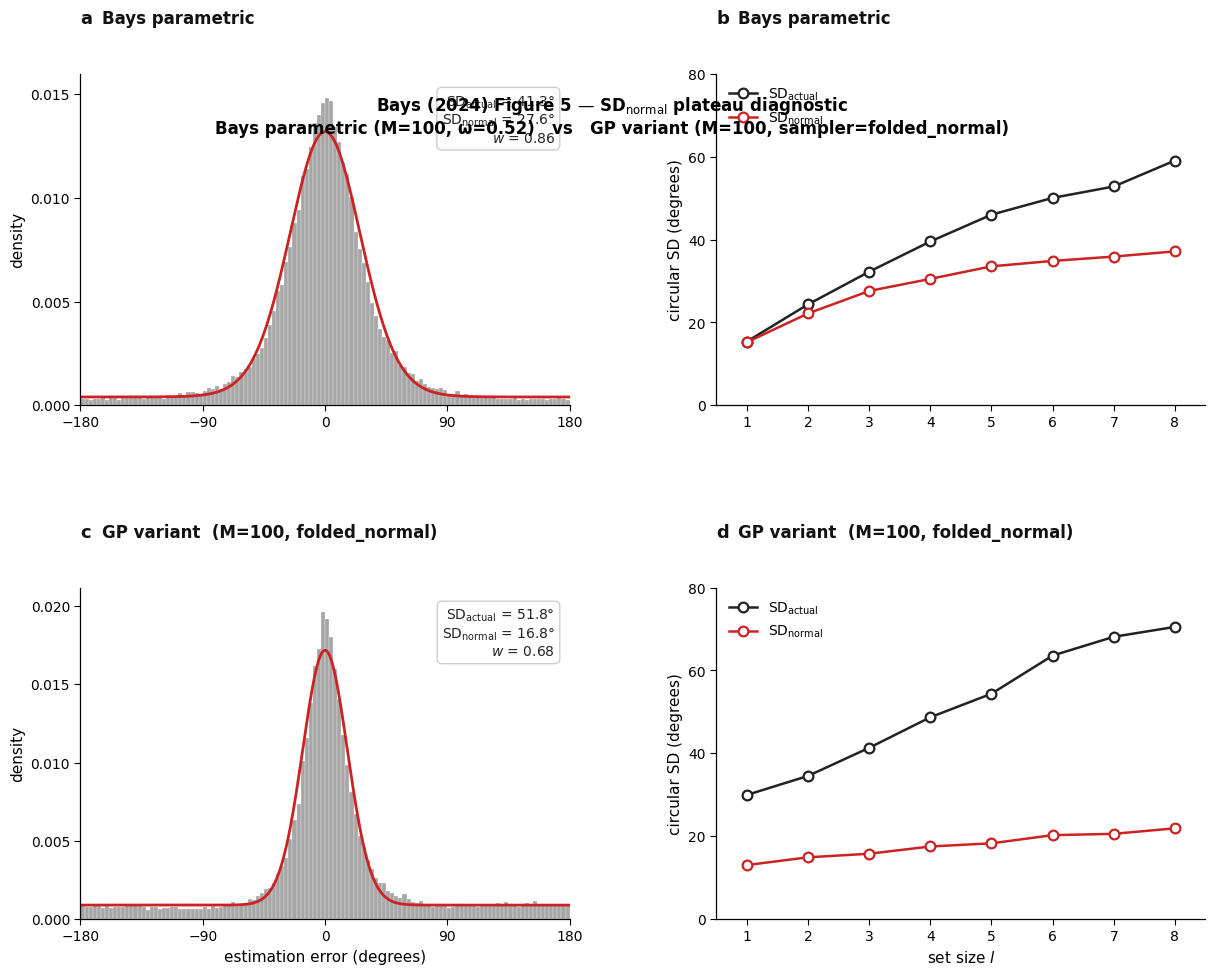

In [14]:
# Style -- match Bays Fig 5: SD_actual in black, SD_normal in red.
BLACK = "#222222"
RED   = "#CC2222"
GRAY  = "#777777"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "font.family": "DejaVu Sans",
})


def mixture_pdf(eps_rad, w, kappa):
    """Normal+uniform mixture density on the circle (input in radians)."""
    vm = np.exp(kappa * np.cos(eps_rad)) / (2.0 * np.pi * i0(kappa))
    return w * vm + (1.0 - w) * (1.0 / (2.0 * np.pi))


# Shared axes infrastructure
edges_deg    = np.linspace(-180, 180, HIST_N_BINS + 1)
eps_grid_deg = np.linspace(-180, 180, 500)
eps_grid_rad = np.deg2rad(eps_grid_deg)

ns = np.array(SET_SIZES, dtype=float)
sd_actual_bays = np.array([np.rad2deg(bays_results[N]["sd_actual"]) for N in SET_SIZES])
sd_normal_bays = np.array([np.rad2deg(bays_results[N]["sd_normal"]) for N in SET_SIZES])
sd_actual_gp   = np.array([np.rad2deg(gp_results[N]["sd_actual"])   for N in SET_SIZES])
sd_normal_gp   = np.array([np.rad2deg(gp_results[N]["sd_normal"])   for N in SET_SIZES])

# --- Refined y-axis for the SD-vs-l panels -----------------------------
# Anchor at 0, ceil to next multiple of 10 above max SD_actual, ticks every
# 10 degrees so the interesting structure (cross-over, plateau) is readable.
y_max_raw = max(sd_actual_bays.max(), sd_actual_gp.max())
Y_MAX_B = int(np.ceil(y_max_raw / 10.0) * 10)
# Tick stride: every 20° keeps the axis readable without crowding.
# At max SD ~80-100°, this gives 5-6 ticks total.
Y_TICK_STRIDE = 20
# Also bump Y_MAX_B up to a multiple of the stride so ticks land cleanly.
Y_MAX_B = int(np.ceil(y_max_raw / Y_TICK_STRIDE) * Y_TICK_STRIDE)
Y_TICKS_B = np.arange(0, Y_MAX_B + 1, Y_TICK_STRIDE)

# --- y-axis for histogram panels: density per degree --------------------
# IMPORTANT: do NOT share Y limits across the two histogram panels — their
# peak densities differ a lot (the GP variant has a sharp central spike).
# Sharing means one panel always has wasted whitespace. Instead each panel
# computes its own snug Y limit from its own bars + mixture-PDF peak.

# Suppress automatic grids in this style block
plt.rc("axes", grid=False)
# ----------------------------------------------------------------------

fig = plt.figure(figsize=(12.5, 10.5))
gs = gridspec.GridSpec(
    2, 2,
    hspace=0.55, wspace=0.30,
    left=0.075, right=0.975, bottom=0.075, top=0.84,
)


def _panel_header(ax, letter, model, caption, show_xlabel_pad=False):
    """
    Two-line panel header:
        bold letter + bold model name on line 1
        smaller grey caption on line 2
    """
    ax.set_title("")  # clear any default
    # Line 1: bold letter + model
    ax.text(
        0.0, 1.14, f"{letter}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=13, fontweight="bold", color="#111111",
    )
    ax.text(
        0.045, 1.14, model,
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, fontweight="bold", color="#111111",
    )
    # Line 2: caption
    ax.text(
        0.0, 1.02, caption,
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color="#555555",
    )


def plot_panel_a(ax, all_errors_rad, w, kappa, sd_actual_rad, sd_normal_rad,
                 letter, model, show_xlabel=True):
    """Aggregate error distribution + mixture overlay (degrees)."""
    all_errors_deg = np.rad2deg(all_errors_rad)
    counts, _, _ = ax.hist(all_errors_deg, bins=edges_deg, density=True,
            color=GRAY, alpha=0.65, edgecolor="white", linewidth=0.3)
    pdf_per_deg = mixture_pdf(eps_grid_rad, w, kappa) * (np.pi / 180.0)
    ax.plot(eps_grid_deg, pdf_per_deg, color=RED, lw=2.0)

    # --- Per-panel snug Y limit -------------------------------------
    # Use the larger of (tallest bar, mixture-PDF peak) * 1.08 headroom.
    panel_y_max = max(counts.max(), pdf_per_deg.max()) * 1.08

    ax.set_xlim(-180, 180)
    ax.set_ylim(0, panel_y_max)
    ax.set_xticks([-180, -90, 0, 90, 180])
    # More informative tick density: ~5 ticks across the visible range,
    # forced to "nice" round numbers (0.005, 0.01, 0.015, ...).
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]))
    if show_xlabel:
        ax.set_xlabel("estimation error (degrees)", fontsize=11)
    ax.set_ylabel("density", fontsize=11)
    ax.grid(False)
    _panel_header(
        ax, letter, model,
        caption="",
    )

    ax.text(
        0.97, 0.94,
        f"SD$_\\mathrm{{actual}}$ = {np.rad2deg(sd_actual_rad):.1f}\u00b0\n"
        f"SD$_\\mathrm{{normal}}$ = {np.rad2deg(sd_normal_rad):.1f}\u00b0\n"
        f"$w$ = {w:.2f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#222222",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#cccccc", alpha=0.95),
    )


def plot_panel_b(ax, sd_actual_arr, sd_normal_arr,
                 letter, model, show_xlabel=True):
    """SD_actual (black) vs SD_normal (red) across set sizes."""
    ax.plot(ns, sd_actual_arr, "o-", color=BLACK, lw=1.8, ms=7,
            label=r"SD$_\mathrm{actual}$", mfc="white", mew=1.6)
    ax.plot(ns, sd_normal_arr, "o-", color=RED, lw=1.8, ms=7,
            label=r"SD$_\mathrm{normal}$", mfc="white", mew=1.6)

    ax.set_xticks(SET_SIZES)
    ax.set_xlim(SET_SIZES[0] - 0.5, SET_SIZES[-1] + 0.5)
    ax.set_yticks(Y_TICKS_B)
    ax.set_ylim(0, Y_MAX_B)
    if show_xlabel:
        ax.set_xlabel("set size $l$", fontsize=11)
    ax.set_ylabel("circular SD (degrees)", fontsize=11)
    ax.legend(fontsize=10, loc="upper left", frameon=False)
    ax.grid(False)
    _panel_header(
        ax, letter, model,
        caption="",
    )


# --- Row 1: Bays parametric ---
ax_1a = fig.add_subplot(gs[0, 0])
plot_panel_a(
    ax_1a, bays_all_errors, bays_w_agg, bays_kappa_agg,
    bays_sd_actual_agg, bays_sd_normal_agg,
    letter="a", model="Bays parametric",
    show_xlabel=False,
)

ax_1b = fig.add_subplot(gs[0, 1])
plot_panel_b(
    ax_1b, sd_actual_bays, sd_normal_bays,
    letter="b", model="Bays parametric",
    show_xlabel=False,
)

# --- Row 2: GP variant ---
ax_2a = fig.add_subplot(gs[1, 0])
plot_panel_a(
    ax_2a, gp_all_errors, gp_w_agg, gp_kappa_agg,
    gp_sd_actual_agg, gp_sd_normal_agg,
    letter="c", model=f"GP variant — fitted  (M={M_GP}, {DISTRIBUTION})",
    show_xlabel=True,
)

ax_2b = fig.add_subplot(gs[1, 1])
plot_panel_b(
    ax_2b, sd_actual_gp, sd_normal_gp,
    letter="d", model=f"GP variant — fitted  (M={M_GP}, {DISTRIBUTION})",
    show_xlabel=True,
)

# Figure-level heading — sits above both rows. Tagged with the GP
# experiment parameters so the saved figure is self-documenting.
fig.suptitle(
    r"Bays (2024) Figure 5 — SD$_\mathrm{normal}$ plateau diagnostic" + "\n" +
    f"Bays parametric (M={M}, ω={OMEGA_BAYS})   vs   "
    f"GP variant fitted (M={M_GP}, sampler={DISTRIBUTION}, "
    f"ω̂={OMEGA_HAT:.3f}, γ̂_total={GAMMA_TOTAL_HAT:.0f} Hz)",
    fontsize=12, fontweight="bold", y=0.96,
)

# Save into the timestamped result directory
fig_path = OUTPUT_DIR / f"bays_fig5_M{M_GP}_{DISTRIBUTION}.png"
fig_path_pdf = OUTPUT_DIR / f"bays_fig5_M{M_GP}_{DISTRIBUTION}.pdf"
plt.savefig(fig_path,     dpi=160, bbox_inches="tight")
plt.savefig(fig_path_pdf,              bbox_inches="tight")
print(f"Saved {fig_path}")
print(f"Saved {fig_path_pdf}")
plt.show()
